In [ ]:
import pandas as pd
import numpy as np
import warnings
import optuna
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from datetime import datetime

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFECV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

tqdm.write("📥 Loading dataset...")
df = df
df= df.sample(n=100000,replace=True,random_state =42)
# === Feature Engineering ===
tqdm.write("⚒ Performing feature engineering...")

df['tir_radiance_diff'] = df['img_tir1_radiance'] - df['img_tir2_radiance']
df['pm10'] = df['pm10']

df['smoke_index_temp'] = df['img_mir_temp'] / (df['img_vis_radiance'] + 1e-6)
df['cloud_flag'] = (df['img_tir1_temp']<240).astype(int)
df['cloud_score'] = np.clip((260 - df['img_tir1_temp'])/20,0,1)
df['temp_diff_tir'] = df['img_tir1_temp'] - df['img_tir2_temp']
df['inversion_flag'] = (df['temp_diff_tir'] > 0).astype(int)
df['sat_view_obliquity'] = 90 - df['sat_elevation']   # how slanted the satellite view is
df['sun_view_angle_diff'] = abs(df['sun_azimuth'] - df['sat_azimuth'])  # illumination-view difference
df['sun_obliquity'] = 90 - df['sun_elevation']  # how low the sun is


features = [
    'latitude', 'longitude', 'img_mir_radiance', 'img_mir_temp', #'img_tir1_temp','img_tir2_temp','img_tir1_radiance', 'img_tir2_radiance',,'sat_elevation','sun_obliquity',
    'img_vis_radiance','smoke_index_temp',# ,'sun_elevation','cloud_score','cloud_flag',,'inversion_flag','img_swir_radiance'
    'img_vis_albedo', 'img_wv_radiance', 'img_wv_temp',
    'avg_population','PBLH', 'lulc', 'tir_radiance_diff','sat_view_obliquity','sun_view_angle_diff','sun_azimuth','sat_azimuth', 
    'temp_diff_tir'
]
target = 'pm10'

df = df.dropna(subset=features + [target])
X = df[features]
y = df[target]

# === Split ===
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# # === Scaling ===
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

# === RFECV Feature Selection ===
# tqdm.write("🧪 Step 1: RFECV for feature pruning...")
# cv = KFold(n_splits=10, shuffle=True, random_state=42)
# rfecv = RFECV(estimator=Ridge(), step=1, cv=cv, scoring='r2', min_features_to_select=20)
# rfecv.fit(X_train_scaled, y_train)

# X_train_selected = rfecv.transform(X_train_scaled)
# X_test_selected = rfecv.transform(X_test_scaled)
# selected_features = X.columns[rfecv.support_]
# removed_features_rfecv = list(X.columns[~rfecv.support_])
# tqdm.write(f"❌ Removed features: {removed_features_rfecv}")
# tqdm.write(f"✅ Selected features: {list(selected_features)}")

# X_all_scaled = scaler.transform(X)
# X_reduced = rfecv.transform(X_all_scaled)
# y_reduced = y.reset_index(drop=True)

# === Optuna Hyperparameter Tuning ===
def objective_rf(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 400, 500),
        'max_depth': trial.suggest_int('max_depth', 29, 50),
        'min_samples_split': trial.suggest_int('min_samples_split', 5, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', 6, 7]),
        'random_state': 42,
        'n_jobs': -1
    }
    model = RandomForestRegressor(**params)
    scores = cross_val_score(model, X, y, cv=5, scoring='r2')
    return scores.mean()

tqdm.write("🔍 Step 2: Tuning Random Forest with Optuna...")
study_rf = optuna.create_study(direction='maximize', study_name='RandomForest')
study_rf.optimize(objective_rf, n_trials=30, show_progress_bar=True)
best_rf_params = study_rf.best_params

# === Train Final Model ===
tqdm.write("🚀 Step 3: Training best Random Forest model...")
rf_best = RandomForestRegressor(**best_rf_params)
rf_best.fit(X_train, y_train)

# === Evaluation ===
y_pred = rf_best.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("\n📊 Model Evaluation:")
print(f"R²: {r2:.4f}, RMSE: {rmse:.4f}, MAE: {mae:.4f}")




[I 2025-08-08 03:21:15,590] A new study created in memory with name: RandomForest


📥 Loading dataset...
⚒ Performing feature engineering...
🔍 Step 2: Tuning Random Forest with Optuna...


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2025-08-08 03:22:31,229] Trial 0 finished with value: 0.7195723799995255 and parameters: {'n_estimators': 455, 'max_depth': 39, 'min_samples_split': 16, 'min_samples_leaf': 6, 'max_features': 'log2'}. Best is trial 0 with value: 0.7195723799995255.
[I 2025-08-08 03:24:22,198] Trial 1 finished with value: 0.7200786894501602 and parameters: {'n_estimators': 467, 'max_depth': 42, 'min_samples_split': 7, 'min_samples_leaf': 4, 'max_features': 7}. Best is trial 1 with value: 0.7200786894501602.
[I 2025-08-08 03:26:36,454] Trial 2 finished with value: 0.7200897950194525 and parameters: {'n_estimators': 498, 'max_depth': 42, 'min_samples_split': 7, 'min_samples_leaf': 4, 'max_features': 7}. Best is trial 2 with value: 0.7200897950194525.
[I 2025-08-08 03:28:08,044] Trial 3 finished with value: 0.7194424853740377 and parameters: {'n_estimators': 445, 'max_depth': 43, 'min_samples_split': 17, 'min_samples_leaf': 7, 'max_features': 6}. Best is trial 2 with value: 0.7200897950194525.
[I 2025-0

In [ ]:
import pandas as pd
df = pd.read_parquet(r"C:\Users\hp\Desktop\PS-03\our_code\abyefinalhai.parquet")
df

,Date,latitude,longitude,pm25,pm10,img_mir_radiance,img_mir_temp,img_swir_radiance,img_tir1_radiance,img_tir1_temp,...,img_vis_albedo,img_wv_radiance,img_wv_temp,PBLH,avg_population,sat_azimuth,sat_elevation,sun_azimuth,sun_elevation,lulc
0,2021-01-15,8.514909,76.943588,16.520000,37.840000,0.043679,290.781586,1.312773,0.520951,263.632935,...,13.258400,0.092012,231.339325,667.463562,176540.915286,14840.473684,7822.263158,20924.368421,5600.421053,16.0
1,2021-01-15,8.524112,76.936057,33.000000,51.750000,0.043498,290.683807,1.350298,0.521067,263.644684,...,13.710799,0.091692,231.251984,667.463562,176540.915286,14838.789474,7821.000000,20922.631579,5600.157895,16.0
2,2021-01-15,8.524112,76.936057,33.000000,38.500000,0.043498,290.683807,1.350298,0.521067,263.644684,...,13.710799,0.091692,231.251984,667.463562,176540.915286,14838.789474,7821.000000,20922.631579,5600.157895,16.0
3,2021-01-15,8.524112,76.936057,33.000000,33.500000,0.043498,290.683807,1.350298,0.521067,263.644684,...,13.710799,0.091692,231.251984,667.463562,176540.915286,14838.789474,7821.000000,20922.631579,5600.157895,16.0
4,2021-01-15,8.524112,76.936057,33.000000,39.000000,0.043498,290.683807,1.350298,0.521067,263.644684,...,13.710799,0.091692,231.251984,667.463562,176540.915286,14838.789474,7821.000000,20922.631579,5600.157895,16.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395094,2023-11-15,34.065992,74.827902,61.900000,69.700000,0.052602,295.190308,0.997179,0.814765,289.112488,...,12.606668,0.168452,247.971497,2206.166504,152346.441429,16816.000000,5065.187500,20389.187500,3518.312500,16.0
395095,2023-11-15,34.065992,74.827902,61.900000,70.000000,0.052602,295.190308,0.997179,0.814765,289.112488,...,12.606668,0.168452,247.971497,2206.166504,152346.441429,16816.000000,5065.187500,20389.187500,3518.312500,16.0
395096,2023-11-15,34.065992,74.827902,61.900000,188.100000,0.052602,295.190308,0.997179,0.814765,289.112488,...,12.606668,0.168452,247.971497,2206.166504,152346.441429,16816.000000,5065.187500,20389.187500,3518.312500,16.0
395097,2023-11-15,34.065992,74.827902,61.900000,187.500000,0.052602,295.190308,0.997179,0.814765,289.112488,...,12.606668,0.168452,247.971497,2206.166504,152346.441429,16816.000000,5065.187500,20389.187500,3518.312500,16.0


In [5]:
# === Permutation Importance ===
tqdm.write("🧮 Step 4: Permutation Importance...")
perm = permutation_importance(rf_best, X_test, y_test, n_repeats=10, random_state=42)
perm_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': perm.importances_mean
}).sort_values(by='Importance', ascending=False)

print("\n📌 Permutation Importance:")
print(perm_importances)

🧮 Step 4: Permutation Importance...

📌 Permutation Importance:
                Feature  Importance
21          sun_azimuth    0.073302
13       avg_population    0.071076
24        temp_diff_tir    0.046155
14                 PBLH    0.046084
0              latitude    0.033683
18  sun_view_angle_diff    0.031834
6      smoke_index_temp    0.031193
17   sat_view_obliquity    0.028782
22        sat_elevation    0.026938
5      img_vis_radiance    0.025714
23          sat_azimuth    0.020423
8        img_vis_albedo    0.020417
20        sun_elevation    0.016874
19        sun_obliquity    0.016676
1             longitude    0.015186
3          img_mir_temp    0.013913
2      img_mir_radiance    0.012985
10          img_wv_temp    0.010111
9       img_wv_radiance    0.010072
4     img_swir_radiance    0.009252
16    tir_radiance_diff    0.008342
15                 lulc    0.006018
11          cloud_score    0.000085
12           cloud_flag    0.000047
7        inversion_flag    0.000011


📈 SHAP Analysis...


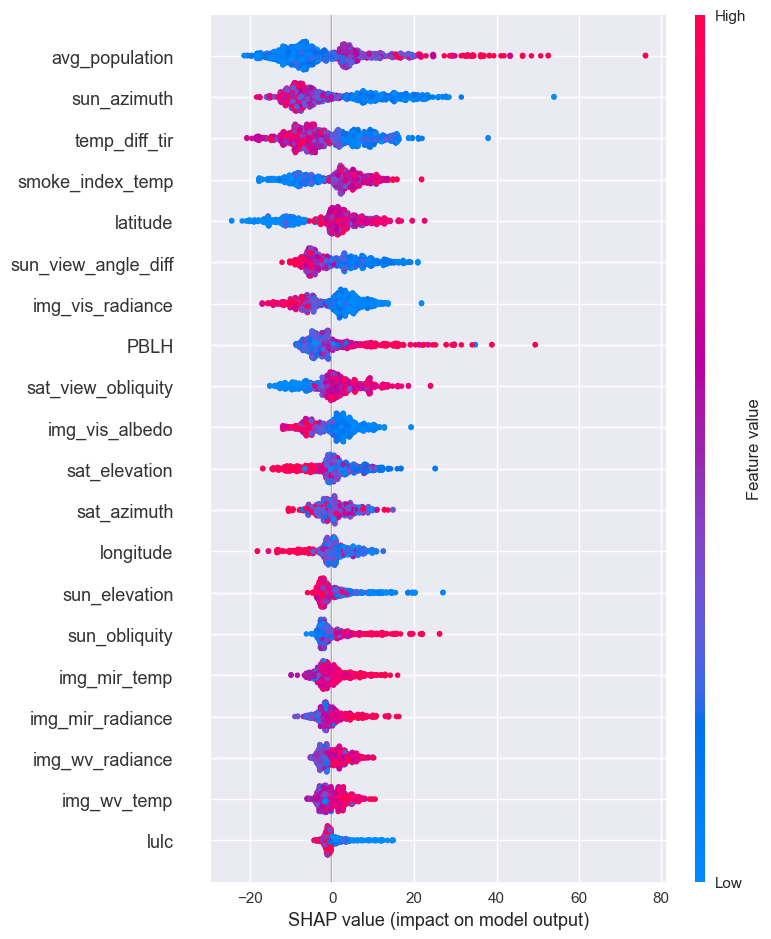

<Figure size 800x550 with 0 Axes>

In [6]:
# === Step 5: SHAP Values ===
import shap
tqdm.write("📈 SHAP Analysis...")
X_shap_sample_df = X_test.sample(n=1000, random_state=42)


explainer = shap.TreeExplainer(rf_best)
shap_values = explainer(X_shap_sample_df)

shap.summary_plot(shap_values, features=X_shap_sample_df, feature_names= X_shap_sample_df.columns)
plt.tight_layout()
plt.show()

In [8]:
# === Step 6: Error Clustering ===
tqdm.write("📉 Error Clustering...")
errors = y_test - y_pred
error_df = pd.DataFrame(X_test.copy())
error_df['Error'] = errors.values
error_cluster = error_df[error_df['Error'].abs() > np.percentile(abs(errors), 90)]

print("\n🔥 Top 10% Error Cluster:")
print(error_cluster.describe())

📉 Error Clustering...

🔥 Top 10% Error Cluster:
          latitude    longitude  img_mir_radiance  img_mir_temp  \
count  1939.000000  1939.000000       1939.000000   1939.000000   
mean     25.247197    80.104479          0.081609    304.107110   
std       5.198861     5.622493          0.029230     11.789632   
min       8.524112    72.587270          0.008448    257.204224   
25%      20.945818    76.791360          0.064807    300.266724   
50%      25.609324    77.064466          0.078714    305.126434   
75%      28.608282    85.123525          0.099499    311.161011   
max      34.065992    93.927888          0.157366    323.858521   

       img_swir_radiance  img_vis_radiance  smoke_index_temp  inversion_flag  \
count        1939.000000       1939.000000       1939.000000     1939.000000   
mean            1.311377          6.648952         64.053036        0.976792   
std             0.426415          5.398186         30.005642        0.150602   
min             0.507176    

In [12]:

# === Step 7: Flagging Misleading Features ===
tqdm.write("🧠 Flagging Misleading Features...")
flagged = []
feature_list = X_test.columns.tolist()
for i,feature in enumerate(feature_list):
    perm_val = perm_importances.loc[perm_importances['Feature'] == feature, 'Importance'].values[0]
    shap_val = np.mean(np.abs(shap_values[:, i].values))
    corr_err = error_df[feature].corr(error_df['Error'])

    if perm_val < 0.001 and shap_val > 0.01 and abs(corr_err) > 0.2:
        flagged.append((feature, perm_val, shap_val, corr_err))

flagged_df = pd.DataFrame(flagged, columns=["Feature", "Permutation Importance", "SHAP", "Correlation with Error"])
print("\n🚨 Misleading Features (Low Perm, High SHAP, High Corr with Error):")
print(flagged_df)

🧠 Flagging Misleading Features...

🚨 Misleading Features (Low Perm, High SHAP, High Corr with Error):
Empty DataFrame
Columns: [Feature, Permutation Importance, SHAP, Correlation with Error]
Index: []
